# Do concepts spread from fields that keep them? — demo

This notebook is a runnable walk-through of the core of `method.py` from the experiment *"Do concepts spread from fields
that keep them?"*.

**The question.** When a new research concept (an OpenAlex concept) enters a new scientific field, which field is it likely to be?
The **retained-frontier** hypothesis says a concept next enters fields that are *related* to the off-home fields that
currently **keep** (retain) it. The covariate is `d0_ret_rel`, the mean relatedness φ of the target field to the retaining fields.
The rival is the field-standard **relatedness density**, built the way the economic-geography literature builds it:
ω = Σ U φ / Σ φ with U = RCA > 1 (Hidalgo 2007; Guevara 2016), plus share-weighted (volume) density.
We also test an **abandonment penalty** (`d_lost`): are fields related to presences the concept has *dropped* entered less often?

**The model.** A conditional logit (Breslow ties) on concept × target-field × year entry risk sets, with concept-year strata.
The ladder of nested models is:
- `R0`: home relatedness, log field size, entered density, own gateway
- `R1`: R0 + `D_rca_1y` (RCA>1 density)
- `R2`: R1 + `D_vol` (share-weighted density)
- `R3`: R2 + `d0_ret_rel` (the retained frontier)
- `R4`: R3 + `d_lost`

Two other models are fitted: `S_strict` (all four RCA variants + both D_vol + d0) and `A1` (R0 + `d_lost`).

**What this demo runs.** The original pipeline builds the risk sets from multi-GB OpenAlex scan arrays that are not
available here. So the demo loads the **already-built held-out risk sets** for a curated subset of **100 held-out concepts**
(25 each from PHYS, LIFEENV, SOC and MATHDEC). They are drawn at random, with the original seed, from concepts that have
≥ 3 informative primary strata. That criterion uses only stratum informativeness, never d0. It also loads the **frozen DEV standardisation**. On that data it runs the
original estimation and analysis code (`lib/models.py`, `lib/analysis.py`, `lib/stats_core.py`, copied verbatim):
- the model ladder and LR tests
- concept-clustered refit bootstraps and the crossed concept × field bootstrap
- the stratum-FE linear probability model, VIF and the Guevara-comparable AUC
- per-unit fits with DerSimonian–Laird pooling
- the volume-matched contrast, the dose response and target-field FE
- held-out predictions from the frozen DEV coefficients

The full-scale published numbers (3,162 concepts) are shown next to the demo numbers at the end.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

## Imports
This is the original import block of `method.py` and of the `lib/` modules it uses. Modules that only serve stages that
are not run here were dropped: `subprocess` (git commits), `resource` (the 26 GB address-space cap) and `networkx`
(backbone rewiring). `matplotlib` is added for the final figures.

In [2]:
from __future__ import annotations

import json
import math
import os

for _v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")  # parallelism comes from the thread map over resamples (lib/models.tmap)
import sys
import time
import zlib
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data loading helper
The data is loaded from the GitHub repository. If that fails, the loader falls back to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_ud-q6jnkjLXa/round-3/experiment-7/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{len(data['examples'])} concepts, {sum(e['n_rows'] for e in data['examples']):,} candidate rows, "
      f"{sum(e['n_entries'] for e in data['examples'])} entry events")

Held-out pooled-4 (PHYS, LIFEENV, SOC, MATHDEC) concept x target-field x year entry risk sets for 100 concepts (25 per unit, drawn at random among concepts with >= 3 informative primary strata) from the EXP5-minus-EXP6 frame; one example = one concept with all its candidate rows (raw, unstandardised covariates at t-1; stratum = concept-year)
100 concepts, 19,012 candidate rows, 458 entry events


## Configuration
These are all the tunable parameters. The values in the original `method.py` are given in the comments; its
environment overrides were `AII_NBOOT`, `AII_NCROSS`, `AII_NUNITBOOT` and `AII_THREADS`. The demo values are smaller so
the notebook finishes within a few minutes on the 100-concept subset. Raise them toward the original values for tighter
bootstrap CIs.

In [5]:
SEED = 20261101            # original seed (unchanged)
N_BOOT = 1000              # concept refit bootstrap draws for the headline estimates   (original: 1000)
N_CROSS = 500              # crossed concept x target-field bootstrap draws            (original: 500)
N_UNIT_BOOT = 500          # bootstrap draws per held-out unit                          (original: 500)
N_THREADS = 4              # thread map over resamples                                  (original: 8)
N_CONCEPTS_PER_UNIT = 25   # concepts used per held-out unit (max 25 in mini_demo_data; original: all 3,162 pooled-4 concepts)
HELD4 = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]

## Held-out risk sets
The original `stage_heldout()` rebuilds this table from scan arrays with `d3.build_strata` and `d3.covariates`, and then
writes `results/risk_sets_exp5_minus_exp6_heldout.parquet`. Here the same rows are rebuilt from the loaded JSON.

Each row is one (concept `cidx`, year `t`, candidate field `field`) triple. A candidate field is one that is not yet
entered and is not a home field. `entered = 1` if the concept entered that field in year `t`. The covariates are raw
values measured at t−1, and `stratum = cidx·100 + (t−2000)` identifies the concept-year.

In [6]:
cols = data["columns"]
ex = [e for u in HELD4 for e in [x for x in data["examples"] if x["unit"] == u][:N_CONCEPTS_PER_UNIT]]
df = pd.DataFrame([r for e in ex for r in e["rows"]], columns=cols)
for c in df.columns:
    if c not in ("unit", "split", "group"):
        df[c] = pd.to_numeric(df[c])
std = data["standardisation_DEV"]   # frozen DEV standardisation (spec["standardisation_DEV"] in stage_heldout)
print(df.shape)
print(df.groupby("unit").agg(concepts=("cidx", "nunique"), rows=("cidx", "size"), events=("entered", "sum")))
df.head()

(19012, 45)
         concepts  rows  events
unit                           
LIFEENV        25  4872     110
MATHDEC        25  4438     114
PHYS           25  4791     110
SOC            25  4911     124


,cidx,t,age,s_idx,field,entered,a_phi_home,b_log_size,c_density,e_gate_own,...,n_pool,unit,split,group,intersect,weak_home,home_med,label_cov,newborn_i,stratum
0,73,2008,1,88,11,0,0.000000,11.604976,0.000000,0.284100,...,1,PHYS,HELDOUT_PHYS,PHYS,0,0,0,0.704545,0,7308
1,73,2008,1,88,12,0,0.000000,11.601769,0.150641,0.025349,...,1,PHYS,HELDOUT_PHYS,PHYS,0,0,0,0.704545,0,7308
2,73,2008,1,88,13,0,0.000000,11.590025,0.000000,0.419023,...,1,PHYS,HELDOUT_PHYS,PHYS,0,0,0,0.704545,0,7308
3,73,2008,1,88,14,0,0.000000,10.535743,0.018834,0.077116,...,1,PHYS,HELDOUT_PHYS,PHYS,0,0,0,0.704545,0,7308
4,73,2008,1,88,15,0,0.240708,4.882802,0.432201,0.963895,...,1,PHYS,HELDOUT_PHYS,PHYS,0,0,0,0.704545,0,7308


## Estimation layer (`lib/stats_core.py` + `lib/models.py`)
This is verbatim code. `FastCLogit` is a Newton conditional logit with this log-likelihood:

ll = Σ_s w_s [ Σ_{e∈s} η_e − nev_s · log Σ_{i∈s} exp η_i ]

It is the Breslow form. It takes stratum weights, which is how the concept-clustered refit bootstrap works (a concept
drawn *m* times gets weight *m*). It also takes row offsets, which the crossed field bootstrap uses. Cluster and two-way
cluster sandwich SEs are built in. `RUNGS` holds the model ladder.

In [7]:
# ---------------------------------------------------------------- lib/stats_core.py (subset used here)
def demean(A: np.ndarray, groups: list[np.ndarray], iters: int = 50, tol: float = 1e-10) -> np.ndarray:
    """Alternating projections to sweep out several sets of fixed effects."""
    A = A.astype(float).copy()
    if A.ndim == 1:
        A = A[:, None]
    for _ in range(iters if len(groups) > 1 else 1):
        prev = A.copy()
        for g in groups:
            _, inv = np.unique(g, return_inverse=True)
            cnt = np.bincount(inv)
            for j in range(A.shape[1]):
                A[:, j] -= (np.bincount(inv, weights=A[:, j]) / cnt)[inv]
        if len(groups) > 1 and np.abs(A - prev).max() < tol:
            break
    return A


def fe_ols(y: np.ndarray, X: np.ndarray, fe: list[np.ndarray], cluster: np.ndarray, names: list[str]) -> dict:
    """OLS of y on X after sweeping out fixed effects `fe`; CRV1 SEs clustered on `cluster` (small-sample corrected)."""
    ok = np.isfinite(y) & np.isfinite(X).all(1)
    y, X, cluster = y[ok], X[ok], cluster[ok]
    fe = [g[ok] for g in fe]
    Z = demean(np.column_stack([y, X]), fe) if fe else np.column_stack([y - y.mean(), X - X.mean(0)])
    yd, Xd = Z[:, 0], Z[:, 1:]
    XtX = Xd.T @ Xd
    try:
        XtXi = np.linalg.pinv(XtX)
    except np.linalg.LinAlgError:
        return {"error": "singular"}
    b = XtXi @ Xd.T @ yd
    e = yd - Xd @ b
    _, cinv = np.unique(cluster, return_inverse=True)
    G = cinv.max() + 1
    sc = np.zeros((G, Xd.shape[1]))
    np.add.at(sc, cinv, Xd * e[:, None])
    n, k = Xd.shape
    corr = G / max(G - 1, 1) * (n - 1) / max(n - k, 1)
    V = corr * XtXi @ (sc.T @ sc) @ XtXi
    se = np.sqrt(np.clip(np.diag(V), 0, None))
    tcrit = stats.t.ppf(0.975, max(G - 1, 1))
    out = {"n": int(n), "n_clusters": int(G), "coef": {}, "V": V.tolist()}
    for i, nm in enumerate(names):
        out["coef"][nm] = {"b": float(b[i]), "se": float(se[i]), "ci": [float(b[i] - tcrit * se[i]), float(b[i] + tcrit * se[i])],
                           "p": float(2 * stats.t.sf(abs(b[i] / se[i]), max(G - 1, 1))) if se[i] > 0 else float("nan")}
    out["_b"] = b
    return out


def dersimonian_laird(b: np.ndarray, se: np.ndarray) -> dict:
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    k = len(b)
    if k == 0:
        return {"k": 0}
    w = 1 / se**2
    bf = (w * b).sum() / w.sum()
    Q = float((w * (b - bf) ** 2).sum())
    C = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / C) if k > 1 and C > 0 else 0.0
    ws = 1 / (se**2 + tau2)
    bre = (ws * b).sum() / ws.sum()
    sre = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    return {"k": k, "b": float(bre), "se": sre, "ci": [float(bre - 1.96 * sre), float(bre + 1.96 * sre)],
            "p": float(2 * stats.norm.sf(abs(bre / sre))), "tau2": float(tau2), "Q": Q, "I2": float(I2)}


# ---------------------------------------------------------------- lib/h2_exp6.py (within-stratum AUC)
def within_auc(df: pd.DataFrame, score: np.ndarray) -> pd.Series:
    """mean-rank AUC per informative stratum."""
    d = pd.DataFrame({"s": df.stratum.to_numpy(), "y": df.entered.to_numpy(), "x": score})
    d["r"] = d.groupby("s").x.rank(method="average")
    g = d.groupby("s").agg(ntot=("y", "size"), nev=("y", "sum"))
    re = d[d.y == 1].groupby("s").r.sum()
    g = g.join(re.rename("rs")).fillna({"rs": 0})
    g = g[(g.nev > 0) & (g.nev < g.ntot)]
    nn = g.ntot - g.nev
    return (g.rs - g.nev * (g.nev + 1) / 2) / (g.nev * nn)

In [8]:
# ---------------------------------------------------------------- lib/models.py
def tmap(fn, items) -> list:
    """deterministic thread map (numpy releases the GIL in the heavy kernels); order of results = order of items."""
    items = list(items)
    if N_THREADS <= 1 or len(items) < 4:
        return [fn(x) for x in items]
    with ThreadPoolExecutor(N_THREADS) as ex:
        return list(ex.map(fn, items))


BASE = ["a_phi_home", "b_log_size", "c_density", "e_gate_own"]
RIVALS_STRICT = ["D_rca_1y", "D_rca_w3", "D_rca_cum", "D_rca_pers", "D_vol", "D_vol_w3"]
RUNGS = {
    "R0_M0": BASE,
    "R1_rca": BASE + ["D_rca_1y"],
    "R2_vol": BASE + ["D_rca_1y", "D_vol"],
    "R3_ret": BASE + ["D_rca_1y", "D_vol", "d0_ret_rel"],
    "R4_lost": BASE + ["D_rca_1y", "D_vol", "d0_ret_rel", "d_lost"],
    "S_strict0": BASE + RIVALS_STRICT,
    "S_strict": BASE + RIVALS_STRICT + ["d0_ret_rel"],
    "S_pca0": BASE + ["RCA_PC1", "D_vol", "D_vol_w3"],
    "S_pca": BASE + ["RCA_PC1", "D_vol", "D_vol_w3", "d0_ret_rel"],
    "A1_lost": BASE + ["d_lost"],
    "EXP6_M1": BASE + ["d0_ret_rel"],
    "EXP6_M2lost": BASE + ["d_lost_gate"],
}
LADDER = [("R1_rca", "R0_M0"), ("R2_vol", "R1_rca"), ("R3_ret", "R2_vol"), ("R4_lost", "R3_ret"),
          ("S_strict", "S_strict0"), ("S_pca", "S_pca0"), ("A1_lost", "R0_M0"), ("EXP6_M1", "R0_M0"), ("EXP6_M2lost", "R0_M0")]
STD_COLS = ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d0_ret_rel", "d_ret_gate", "d_lost_gate", "d_lost",
            "D_rca_1y", "D_rca_w3", "D_rca_cum", "D_rca_pers", "D_vol", "D_vol_w3", "D_cum", "d_lost_short", "d_lost_long"]
D0_SCALE_COLS = ["d_ret_a2", "d_ret_a3", "d_ret_a4p", "d_R_m", "d_N_m", "d_R_mf", "d_N_mf"]  # common scale = SD of d0_ret_rel


class FastCLogit:
    """ll = sum_s w_s [ sum_{e in s} eta_e - nev_s log sum_{i in s} exp(eta_i) ],  eta = X b + offset.
    Only informative strata (>= 1 event and >= 1 non-event) are kept."""

    def __init__(self, X: np.ndarray, y: np.ndarray, strata: np.ndarray, offset: np.ndarray | None = None,
                 clusters: dict[str, np.ndarray] | None = None):
        o = np.argsort(strata, kind="stable")
        s = strata[o]
        _, starts, counts = np.unique(s, return_index=True, return_counts=True)
        yy = y[o].astype(np.float64)
        nev = np.add.reduceat(yy, starts)
        keep_s = (nev > 0) & (nev < counts)
        rows = np.repeat(keep_s, counts)
        self.idx = o[rows]                      # original row index of every internal row
        self.X = np.ascontiguousarray(X[self.idx], dtype=np.float64)
        self.y = yy[rows]
        self.off = None if offset is None else offset[self.idx].astype(np.float64)
        s = s[rows]
        self.sid, self.starts, self.counts = np.unique(s, return_index=True, return_counts=True)
        self.nev = np.add.reduceat(self.y, self.starts) if len(self.starts) else np.zeros(0)
        self.row_s = np.repeat(np.arange(len(self.starts)), self.counts)
        self.clusters = {k: v[self.idx] for k, v in (clusters or {}).items()}
        self.w = np.ones(len(self.starts))

    @property
    def n_strata(self) -> int:
        return int(len(self.starts))

    def set_col(self, j: int, values: np.ndarray) -> None:
        self.X[:, j] = values[self.idx]

    def _parts(self, b: np.ndarray, w: np.ndarray):
        eta = self.X @ b
        if self.off is not None:
            eta = eta + self.off
        m = np.maximum.reduceat(eta, self.starts)
        e = np.exp(eta - m[self.row_s])
        S = np.add.reduceat(e, self.starts)
        p = e / S[self.row_s]
        lse = np.log(S) + m
        ll = float((w[self.row_s] * self.y * eta).sum() - (w * self.nev * lse).sum())
        return eta, p, ll

    def fit(self, b0: np.ndarray | None = None, w: np.ndarray | None = None, ridge: float = 0.0, tol: float = 1e-9,
            maxit: int = 60, want_cov: bool = True) -> dict:
        k = self.X.shape[1]
        if self.n_strata == 0:
            return {"coef": np.full(k, np.nan), "se": np.full(k, np.nan), "ll": np.nan, "converged": False,
                    "n_strata": 0, "n_events": 0, "n_rows": 0, "max_grad": np.nan}
        w = self.w if w is None else w
        b = np.zeros(k) if b0 is None else np.array(b0, float)
        _, p, ll = self._parts(b, w)
        ll -= 0.5 * ridge * b @ b
        conv = False
        for it in range(maxit):
            wr = w[self.row_s]
            Ex = np.add.reduceat(p[:, None] * self.X, self.starts)
            g = (wr * self.y) @ self.X - (w * self.nev) @ Ex - ridge * b
            A = self.X * np.sqrt(wr * self.nev[self.row_s] * p)[:, None]
            B = Ex * np.sqrt(w * self.nev)[:, None]
            H = A.T @ A - B.T @ B + ridge * np.eye(k)
            try:
                step = np.linalg.solve(H, g)
            except np.linalg.LinAlgError:
                step = np.linalg.lstsq(H, g, rcond=None)[0]
            t = 1.0
            for _ in range(30):
                bn = b + t * step
                _, pn, lln = self._parts(bn, w)
                lln -= 0.5 * ridge * bn @ bn
                if lln >= ll - 1e-10:
                    break
                t *= 0.5
            b, p, dll = bn, pn, lln - ll
            ll = lln
            if np.abs(t * step).max() < tol or abs(dll) < 1e-12:
                conv = True
                break
        wr = w[self.row_s]
        Ex = np.add.reduceat(p[:, None] * self.X, self.starts)
        g = (wr * self.y) @ self.X - (w * self.nev) @ Ex - ridge * b
        out = {"coef": b, "ll": ll, "converged": bool(conv and np.abs(g).max() < 1e-4), "max_grad": float(np.abs(g).max()),
               "n_strata": self.n_strata, "n_events": int(self.y.sum()), "n_rows": int(len(self.y)), "iters": it + 1}
        if want_cov:
            A = self.X * np.sqrt(wr * self.nev[self.row_s] * p)[:, None]
            B = Ex * np.sqrt(w * self.nev)[:, None]
            H = A.T @ A - B.T @ B + ridge * np.eye(k)
            try:
                Hi = np.linalg.inv(H)
                out["se"] = np.sqrt(np.clip(np.diag(Hi), 0, None))
            except np.linalg.LinAlgError:
                Hi = np.linalg.pinv(H)
                out["se"] = np.full(k, np.nan)
            out["_Hi"] = Hi
            out["_p"] = p
        return out

    def row_scores(self, res: dict) -> np.ndarray:
        """per-row score contributions u_i = (y_i - nev_s p_i) x_i (sum within stratum = stratum score)."""
        return (self.y - self.nev[self.row_s] * res["_p"])[:, None] * self.X

    def cluster_se(self, res: dict, by: str | list[str]) -> np.ndarray:
        """CRV1 sandwich; `by` a cluster name, or two names for Cameron-Gelbach-Miller two-way clustering."""
        U = self.row_scores(res)
        Hi = res["_Hi"]

        def meat(key: np.ndarray) -> tuple[np.ndarray, int]:
            _, inv = np.unique(key, return_inverse=True)
            G = inv.max() + 1
            sc = np.zeros((G, U.shape[1]))
            np.add.at(sc, inv, U)
            return (G / max(G - 1, 1)) * (sc.T @ sc), G
        if isinstance(by, str):
            M, _ = meat(self.clusters[by])
        else:
            a, b = (self.clusters[x] for x in by)
            Ma, _ = meat(a); Mb, _ = meat(b)
            Mab, _ = meat(a.astype(np.int64) * 1000 + b.astype(np.int64))
            M = Ma + Mb - Mab
        V = Hi @ M @ Hi
        return np.sqrt(np.clip(np.diag(V), 0, None))

In [9]:
# ---------------------------------------------------------------- lib/models.py (helpers)
def standardise(df: pd.DataFrame, spec: dict) -> pd.DataFrame:
    out = df.copy()
    for c, v in spec.items():
        if c in out and "mean" in v:
            out[c] = (df[c] - v["mean"]) / (v["sd"] if v["sd"] > 0 else 1.0)
    if "RCA_PC1" in spec and all(c in out for c in spec["RCA_PC1"]["cols"]):
        p = spec["RCA_PC1"]
        out["RCA_PC1"] = (out[p["cols"]].to_numpy() @ np.array(p["loadings"]) - p["pc_mean"]) / p["pc_sd"]
    return out


def model(df: pd.DataFrame, cols: list[str], offset: np.ndarray | None = None) -> FastCLogit:
    return FastCLogit(df[cols].to_numpy(np.float64), df.entered.to_numpy(), df.stratum.to_numpy(), offset=offset,
                      clusters={"concept": df.cidx.to_numpy(), "field": df.field.to_numpy()})


def summarise(m: FastCLogit, r: dict, cols: list[str], cluster: bool = True) -> dict:
    out = {"coef": dict(zip(cols, map(float, r["coef"]))), "se_model": dict(zip(cols, map(float, r["se"]))),
           "ll": float(r["ll"]), "n_strata": r["n_strata"], "n_events": r["n_events"], "n_rows": r["n_rows"],
           "converged": r["converged"], "max_grad": r["max_grad"]}
    if cluster and r["n_strata"] > 0:
        out["se_concept"] = dict(zip(cols, map(float, m.cluster_se(r, "concept"))))
    return out


def lr(big: dict, small: dict, df_: int = 1) -> dict:
    x = 2 * (big["ll"] - small["ll"])
    return {"LR": float(x), "df": df_, "p": float(stats.chi2.sf(max(x, 0), df_))}


def fit_ladder(df: pd.DataFrame, rungs: list[str] | None = None, auc: bool = True, two_way: list[str] | None = None) -> dict:
    """fit every rung on the same rows; LR along LADDER; within-stratum AUC of each linear predictor."""
    rungs = rungs or list(RUNGS)
    fits, res = {}, {"models": {}, "LR": {}, "auc_within": {}}
    for rn in rungs:
        cols = RUNGS[rn]
        m = model(df, cols)
        r = m.fit()
        fits[rn] = r
        res["models"][rn] = summarise(m, r, cols)
        if two_way and rn in two_way:
            res["models"][rn]["se_two_way_concept_field"] = dict(zip(cols, map(float, m.cluster_se(r, ["concept", "field"]))))
        if auc:
            sc = df[cols].to_numpy() @ r["coef"]
            res["auc_within"][rn] = float(within_auc(df, sc).mean())
    for big, small in LADDER:
        if big in fits and small in fits:
            res["LR"][f"{big}_vs_{small}"] = lr(fits[big], fits[small], len(RUNGS[big]) - len(RUNGS[small]))
    res["n"] = {"rows": int(len(df)), "strata": int(df.stratum.nunique()), "concepts": int(df.cidx.nunique()),
                "events": int(df.entered.sum()), "informative_strata": fits[rungs[0]]["n_strata"],
                "informative_rows": fits[rungs[0]]["n_rows"]}
    res["_fits"] = fits
    return res


def concept_weights(cid_of_stratum: np.ndarray, rng, n_boot: int) -> np.ndarray:
    """multinomial concept-resampling counts mapped to strata -> [n_boot, n_strata]. A concept drawn m times
    contributes m identical independent copies of its strata, i.e. weight m (exact equivalence with the
    duplicate-and-relabel refit bootstrap of h2_exp6.boot_coef)."""
    u, inv = np.unique(cid_of_stratum, return_inverse=True)
    W = np.empty((n_boot, len(cid_of_stratum)))
    for b in range(n_boot):
        cnt = np.bincount(rng.integers(0, len(u), len(u)), minlength=len(u)).astype(float)
        W[b] = cnt[inv]
    return W


def boot_refit(df: pd.DataFrame, cols: list[str], targets: list[str], n_boot: int, rng, small_cols: list[str] | None = None,
               W: np.ndarray | None = None) -> dict:
    """concept-clustered refit bootstrap (weights), warm-started at the full-sample estimate."""
    m = model(df, cols)
    r0 = m.fit(want_cov=False)
    ms = model(df, small_cols) if small_cols else None
    rs0 = ms.fit(want_cov=False) if ms else None
    if W is None:
        W = concept_weights(m.sid // 100, rng, n_boot)
    def one(w):
        r = m.fit(b0=r0["coef"], w=w, want_cov=False)
        lrv = 2 * (r["ll"] - ms.fit(b0=rs0["coef"], w=w, want_cov=False)["ll"]) if ms is not None else None
        return r["coef"], lrv
    got = tmap(one, W)
    B = np.array([g[0] for g in got])
    L = [g[1] for g in got if g[1] is not None]
    out = {"resampling_unit": "concept", "n_boot": int(len(W))}
    for tg in targets:
        j = cols.index(tg)
        out[tg] = {"est": float(r0["coef"][j]), "ci": [float(np.nanpercentile(B[:, j], 2.5)), float(np.nanpercentile(B[:, j], 97.5))],
                   "se_boot": float(np.nanstd(B[:, j])), "p_one_sided_le0": float((1 + (B[:, j] <= 0).sum()) / (1 + len(B)))}
    if L:
        L = np.array(L)
        out["LR_boot_q"] = [float(x) for x in np.percentile(L, [5, 25, 50, 75, 95])]
    out["_B"] = B
    return out


def contrast_boot(df: pd.DataFrame, cols: list[str], a: str, b: str, n_boot: int, rng, sign: int = 1) -> dict:
    """bootstrap CI of coef[a] - coef[b] (concept refit)."""
    bt = boot_refit(df, cols, [a, b], n_boot, rng)
    d = bt["_B"][:, cols.index(a)] - bt["_B"][:, cols.index(b)]
    est = bt[a]["est"] - bt[b]["est"]
    return {"resampling_unit": "concept", "n_boot": n_boot, "est": float(est),
            "ci": [float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))],
            "p_one_sided": float((1 + (sign * d <= 0).sum()) / (1 + len(d))), a: bt[a], b: bt[b]}


def crossed_boot(df: pd.DataFrame, cols: list[str], target: str, n_boot: int, rng) -> dict:
    """Owen pigeonhole: concept weights u_c ~ Poisson(1) on stratum log-lik; target-field weights v_k ~ Poisson(1) as
    offset log(v_k) on each alternative (v_k = 0 removes the alternative; strata left uninformative drop out)."""
    m0 = model(df, cols)
    b0 = m0.fit(want_cov=False)["coef"]
    fk = df.field.to_numpy() - 11
    cid = df.cidx.to_numpy()
    uc, cinv = np.unique(cid, return_inverse=True)
    draws = [(rng.poisson(1.0, 26).astype(float), rng.poisson(1.0, len(uc)).astype(float)) for _ in range(n_boot)]
    Xall, yall, sall = df[cols].to_numpy(np.float64), df.entered.to_numpy(), df.stratum.to_numpy()

    def one(vu):
        v, u = vu
        keep = (v[fk] > 0) & (u[cinv] > 0)
        m = FastCLogit(Xall[keep], yall[keep], sall[keep], offset=np.log(v[fk][keep]))
        if m.n_strata == 0:
            return np.nan
        ws = u[np.searchsorted(uc, m.sid // 100)]
        return m.fit(b0=b0, w=ws, want_cov=False)["coef"][cols.index(target)]
    B = np.array(tmap(one, draws))
    B = B[np.isfinite(B)]
    return {"resampling_unit": "concept x target field (Owen pigeonhole, Poisson(1) weights)", "n_boot": int(len(B)),
            "ci": [float(np.percentile(B, 2.5)), float(np.percentile(B, 97.5))], "se_boot": float(B.std())}


def lpm(df: pd.DataFrame, cols: list[str]) -> dict:
    """linear probability model with concept-year (stratum) FE, concept-clustered CRV1 SEs (econ-geo comparability)."""
    r = fe_ols(df.entered.to_numpy(float), df[cols].to_numpy(float), [df.stratum.to_numpy()], df.cidx.to_numpy(), cols)
    r.pop("V", None); r.pop("_b", None)
    r["resampling_unit"] = "concept (CRV1 clusters)"
    r["base_rate"] = float(df.entered.mean())
    return r


def dl(b: list[float], se: list[float]) -> dict:
    return dersimonian_laird(np.array(b), np.array(se))


def informative(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby("stratum").entered.agg(["sum", "size"])
    ok = g.index[(g["sum"] > 0) & (g["sum"] < g["size"])]
    return df[df.stratum.isin(ok)]

## Analysis layer (`lib/analysis.py`)
This is verbatim code for the parts of the battery that work from the risk-set table alone:
- the ladder and the abandonment block
- the headline bootstraps
- the per-unit fits and DerSimonian–Laird pooling
- VIF and the Guevara-comparable AUC

**Not run here.** Some nulls need the per-stratum field *sets* (RET/POOL masks) and the φ backbone, which live in the
scan arrays: the retained-label permutation, backbone rewiring and node-label permutation. So do the rebuild
sensitivities (min_n 3/5, RCA entry event, primary-topic fields, min-CP proximity), because they re-derive the risk sets
from those arrays. At full scale these gave permutation p = 0.001, rewire p = 0.004 and node-label p = 0.003 (see the
summary).

In [10]:
RUNGS.update({
    "A1_split": BASE + ["d_lost_short", "d_lost_long"],
    "VM0": RUNGS["R2_vol"],
    "VM": RUNGS["R2_vol"] + ["d_R_m", "d_N_m"],
    "VMF": RUNGS["R2_vol"] + ["d_R_mf", "d_N_mf"],
    "DOSE": RUNGS["R2_vol"] + ["d_ret_a2", "d_ret_a3", "d_ret_a4p"],
    "R3_Dcum": RUNGS["R3_ret"] + ["D_cum"],
    "R2_Dcum": RUNGS["R2_vol"] + ["D_cum"],
})
PRIM_RUNGS = ["R0_M0", "R1_rca", "R2_vol", "R3_ret", "R4_lost", "S_strict0", "S_strict", "S_pca0", "S_pca", "EXP6_M1", "EXP6_M2lost"]


def rng_for(seed: int, tag: str) -> np.random.Generator:
    return np.random.default_rng([seed, zlib.crc32(tag.encode())])


def split_std(df_all: pd.DataFrame, spec: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    """(primary = strata with a non-empty retained set [EXP6 convention], all candidate rows), both standardised."""
    alls = standardise(df_all, spec)
    return alls[df_all.n_ret.to_numpy() > 0], alls


def coef_row(df: pd.DataFrame, cols: list[str], target: str, small: list[str] | None = None) -> dict:
    m = model(df, cols)
    r = m.fit()
    j = cols.index(target)
    out = {"coef": float(r["coef"][j]), "se_model": float(r["se"][j]), "n_strata": r["n_strata"], "n_events": r["n_events"],
           "n_concepts": int(df.cidx.nunique()), "converged": r["converged"]}
    if r["n_strata"] > 0:
        out["se_concept"] = float(m.cluster_se(r, "concept")[j])
        out["p_wald_concept_2s"] = float(2 * stats.norm.sf(abs(out["coef"] / out["se_concept"]))) if out["se_concept"] > 0 else None
    if small is not None:
        rs = model(df, small).fit(want_cov=False)
        out["LR"] = lr(r, rs, len(cols) - len(small))
    return out


def sens_pair(prim: pd.DataFrame, alls: pd.DataFrame, extra: list[str] | None = None, drop: list[str] | None = None) -> dict:
    """d0 in R3 (LR vs R2) on the primary sample and d_lost in A1 (LR vs R0) on all rows."""
    extra = extra or []
    drop = drop or []
    f = lambda c: [x for x in c if x not in drop] + extra  # noqa: E731
    return {"d0_R3": coef_row(prim, f(RUNGS["R3_ret"]), "d0_ret_rel", f(RUNGS["R2_vol"])),
            "d_lost_A1": coef_row(alls, f(RUNGS["A1_lost"]), "d_lost", f(RUNGS["R0_M0"]))}


def vif_block(prim: pd.DataFrame, cols: list[str]) -> dict:
    d = informative(prim)
    Z = d[cols].to_numpy(float)
    _, inv = np.unique(d.stratum.to_numpy(), return_inverse=True)
    cnt = np.bincount(inv)
    for j in range(Z.shape[1]):
        Z[:, j] -= (np.bincount(inv, weights=Z[:, j]) / cnt)[inv]
    Z = Z / np.maximum(Z.std(0), 1e-12)
    Cm = np.corrcoef(Z, rowvar=False)
    try:
        vif = np.diag(np.linalg.inv(Cm))
    except np.linalg.LinAlgError:
        vif = np.full(len(cols), np.inf)
    return {"vif_within_stratum": dict(zip(cols, map(float, vif))), "condition_number": float(np.linalg.cond(Z)),
            "corr_within": pd.DataFrame(Cm, index=cols, columns=cols).round(3).to_dict()}


def ladder_block(prim: pd.DataFrame, alls: pd.DataFrame) -> dict:
    lad = fit_ladder(prim, PRIM_RUNGS, two_way=["R3_ret"])
    lad.pop("_fits")
    ab = fit_ladder(alls, ["R0_M0", "A1_lost", "A1_split"], two_way=["A1_lost"])
    ab.pop("_fits")
    ab["LR"]["A1_split_vs_R0_M0"] = lr({"ll": ab["models"]["A1_split"]["ll"]}, {"ll": ab["models"]["R0_M0"]["ll"]}, 2)
    return {"frontier_primary_sample": lad, "abandonment_all_rows": ab}


def headline_boots(prim: pd.DataFrame, alls: pd.DataFrame, rng, n_boot: int, second_seed: bool = False) -> dict:
    t = time.time()
    out = {"d0_R3": boot_refit(prim, RUNGS["R3_ret"], ["d0_ret_rel"], n_boot, rng, small_cols=RUNGS["R2_vol"]),
           "d0_S_strict": boot_refit(prim, RUNGS["S_strict"], ["d0_ret_rel"], n_boot, rng, small_cols=RUNGS["S_strict0"]),
           "d0_S_pca": boot_refit(prim, RUNGS["S_pca"], ["d0_ret_rel"], n_boot, rng, small_cols=RUNGS["S_pca0"]),
           "d_lost_A1": boot_refit(alls, RUNGS["A1_lost"], ["d_lost"], n_boot, rng, small_cols=RUNGS["R0_M0"]),
           "R4": boot_refit(prim, RUNGS["R4_lost"], ["d0_ret_rel", "d_lost"], n_boot, rng)}
    if second_seed:
        b2 = boot_refit(prim, RUNGS["R3_ret"], ["d0_ret_rel"], n_boot, np.random.default_rng(rng.integers(1 << 31)))
        a, b = out["d0_R3"]["d0_ret_rel"]["ci"], b2["d0_ret_rel"]["ci"]
        out["T6_seed_stability_d0_R3"] = {"ci_seed1": a, "ci_seed2": b, "max_endpoint_shift": float(max(abs(a[0] - b[0]), abs(a[1] - b[1]))),
                                          "pass_lt_0.01": bool(max(abs(a[0] - b[0]), abs(a[1] - b[1])) < 0.01)}
    for v in out.values():
        if isinstance(v, dict):
            v.pop("_B", None)
    logger.info(f"headline bootstraps ({n_boot}) in {time.time()-t:.0f}s")
    return out


def unit_fits(prim: pd.DataFrame, alls: pd.DataFrame, unit_col: str, units: list[str], rng, n_boot: int) -> dict:
    out = {}
    for u in units:
        p, a = prim[prim[unit_col] == u], alls[alls[unit_col] == u]
        if p.cidx.nunique() < 5:
            out[u] = {"status": "too few concepts", "n_concepts": int(p.cidx.nunique())}
            continue
        r = sens_pair(p, a)
        bt = boot_refit(p, RUNGS["R3_ret"], ["d0_ret_rel"], n_boot, rng)
        r["d0_R3"]["boot_ci"] = bt["d0_ret_rel"]["ci"]
        bl = boot_refit(a, RUNGS["A1_lost"], ["d_lost"], n_boot, rng)
        r["d_lost_A1"]["boot_ci"] = bl["d_lost"]["ci"]
        r["resampling_unit"] = "concept"
        r["n_boot"] = n_boot
        r["within_auc_R3_vs_R2"] = {}
        for rn in ("R2_vol", "R3_ret"):
            cols = RUNGS[rn]
            b = model(p, cols).fit(want_cov=False)["coef"]
            r["within_auc_R3_vs_R2"][rn] = float(within_auc(p, p[cols].to_numpy() @ b).mean())
        r["sparsity"] = {"share_strata_any_lost": float(a.groupby("stratum").n_lost.max().gt(0).mean()),
                         "mean_n_lost_per_stratum": float(a.groupby("stratum").n_lost.max().mean())}
        out[u] = r
    return out


def dl_block(units: dict, names: list[str]) -> dict:
    res = {}
    for key, tg in (("d0_R3", "d0"), ("d_lost_A1", "d_lost")):
        use = [u for u in names if key in units.get(u, {})]
        b = [units[u][key]["coef"] for u in use]
        se = [units[u][key].get("se_concept", units[u][key]["se_model"]) for u in use]
        res[tg] = {"units": use, **dl(b, se), "n_positive": int(sum(x > 0 for x in b)), "n_negative": int(sum(x < 0 for x in b)),
                   "se_type": "concept-clustered sandwich"}
    return res


def guevara_auc(df_all: pd.DataFrame, prim: pd.DataFrame, coef_R3: dict) -> dict:
    y = df_all.entered.to_numpy()
    out = {"note": "GLOBAL (pooled, not within-stratum) AUC over all candidate rows; unit = concept x target field x year, "
                   "event = D3 count entry; Guevara et al. 2016 report 0.896 (individuals), 0.715 (organisations), 0.682 "
                   "(countries) for RCA-transition entry into research fields: different unit, event and proximity",
           "D_rca_cum_alone": float(roc_auc_score(y, df_all.D_rca_cum)), "D_rca_1y_alone": float(roc_auc_score(y, df_all.D_rca_1y)),
           "c_density_alone": float(roc_auc_score(y, df_all.c_density)), "b_log_size_alone": float(roc_auc_score(y, df_all.b_log_size))}
    cols = RUNGS["R3_ret"]
    lp = prim[cols].to_numpy() @ np.array([coef_R3[c] for c in cols])
    out["R3_linear_predictor_primary_rows"] = float(roc_auc_score(prim.entered, lp))
    return out

## `battery()` from `method.py`
This is the original battery: ladder, convergence, VIF, LPM, Guevara AUC, sparsity, headline bootstraps and the crossed
bootstrap. The `specificity(...)` and `rebuild_sens(...)` calls at the end need the scan-array state (`st`, `bb`,
`frame`, `G`), so they are cut here. The parts of `specificity` that need only the risk-set table follow in the next
section.

In [11]:
def battery(tag: str, df_all: pd.DataFrame, spec: dict, n_boot: int, full: bool = True) -> dict:
    """ladder + headline bootstraps + LPM + Guevara AUC + VIF (+ crossed bootstrap). [demo: st/bb/frame/G args and the
    specificity/rebuild_sens calls that need the scan arrays are removed]"""
    t = time.time()
    rng = rng_for(SEED, tag)
    prim, alls = split_std(df_all, spec)
    out = {"label": tag, "resampling_unit": "concept"}
    out["ladder"] = ladder_block(prim, alls)
    lad = out["ladder"]["frontier_primary_sample"]
    logger.info(f"[{tag}] ladder: " + ", ".join(f"{k} LR={v['LR']:.2f}" for k, v in lad["LR"].items()))
    logger.info(f"[{tag}] d0 in R3 = {lad['models']['R3_ret']['coef']['d0_ret_rel']:.4f}; "
                f"d0 in S_strict = {lad['models']['S_strict']['coef']['d0_ret_rel']:.4f}; "
                f"d_lost in A1 = {out['ladder']['abandonment_all_rows']['models']['A1_lost']['coef']['d_lost']:.4f}")
    out["convergence"] = {rn: {"converged": v["converged"], "max_grad": v["max_grad"],
                               "max_abs_beta": max(abs(x) for x in v["coef"].values())} for rn, v in lad["models"].items()}
    out["vif"] = vif_block(prim, BASE + RIVALS_STRICT + ["d0_ret_rel", "d_lost"])
    out["lpm_concept_year_FE"] = lpm(prim, RUNGS["R3_ret"])
    out["guevara_comparable_auc"] = guevara_auc(df_all, prim, lad["models"]["R3_ret"]["coef"])
    out["sparsity"] = {"share_strata_any_lost": float(alls.groupby("stratum").n_lost.max().gt(0).mean()),
                       "mean_n_lost_per_stratum": float(alls.groupby("stratum").n_lost.max().mean()),
                       "mean_n_ret_primary": float(prim.groupby("stratum").n_ret.max().mean())}
    if not full:
        return out
    out["boot"] = headline_boots(prim, alls, rng, n_boot, second_seed=True)
    t2 = time.time()
    out["crossed_boot"] = {"d0_R3": crossed_boot(prim, RUNGS["R3_ret"], "d0_ret_rel", N_CROSS, rng),
                           "d_lost_A1": crossed_boot(alls, RUNGS["A1_lost"], "d_lost", N_CROSS, rng)}
    logger.info(f"[{tag}] crossed bootstrap {time.time()-t2:.0f}s: {out['crossed_boot']['d0_R3']['ci']}")
    logger.info(f"[{tag}] battery total {time.time()-t:.0f}s")
    return out

## Held-out pooled-4: run the battery (from `stage_heldout`)
This fits the pooled PHYS+LIFEENV+SOC+MATHDEC held-out sample with the **frozen DEV standardisation**.

**Primary sample.** The frontier rungs use only concept-year strata with a non-empty retained set (`n_ret > 0`). The
abandonment model A1 uses every candidate row.

In [12]:
t_start = time.time()
res = {"label": "HELD-OUT (EXP5 minus EXP6), demo subset, frozen DEV standardisation",
       "n_concepts": df.drop_duplicates("cidx").unit.value_counts().to_dict()}
res["pooled4"] = battery("exp5_heldout_pooled4", df, std, n_boot=N_BOOT, full=True)
lad = res["pooled4"]["ladder"]["frontier_primary_sample"]
print(json.dumps(lad["n"], indent=1))
print(pd.DataFrame(lad["LR"]).T.round(4))

02:10:58|INFO   |[exp5_heldout_pooled4] ladder: R1_rca_vs_R0_M0 LR=0.56, R2_vol_vs_R1_rca LR=0.00, R3_ret_vs_R2_vol LR=9.79, R4_lost_vs_R3_ret LR=0.32, S_strict_vs_S_strict0 LR=6.96, S_pca_vs_S_pca0 LR=6.61, EXP6_M1_vs_R0_M0 LR=10.29, EXP6_M2lost_vs_R0_M0 LR=1.45


02:10:58|INFO   |[exp5_heldout_pooled4] d0 in R3 = 0.2605; d0 in S_strict = 0.2275; d_lost in A1 = -0.0666


02:12:33|INFO   |headline bootstraps (1000) in 95s


02:12:42|INFO   |[exp5_heldout_pooled4] crossed bootstrap 9s: [-0.12977074340135664, 0.5714022174220923]


02:12:42|INFO   |[exp5_heldout_pooled4] battery total 105s


{
 "rows": 18505,
 "strata": 978,
 "concepts": 100,
 "events": 446,
 "informative_strata": 381,
 "informative_rows": 7319
}
                            LR   df       p
R1_rca_vs_R0_M0         0.5572  1.0  0.4554
R2_vol_vs_R1_rca        0.0001  1.0  0.9937
R3_ret_vs_R2_vol        9.7893  1.0  0.0018
R4_lost_vs_R3_ret       0.3247  1.0  0.5688
S_strict_vs_S_strict0   6.9643  1.0  0.0083
S_pca_vs_S_pca0         6.6051  1.0  0.0102
EXP6_M1_vs_R0_M0       10.2873  1.0  0.0013
EXP6_M2lost_vs_R0_M0    1.4525  1.0  0.2281


## Specificity checks that need only the risk-set table (from `analysis.specificity`)
Three checks run on the table alone:
- **(b) Volume-matched contrast.** Compare fields that retain the concept (R) with fields the concept entered but did
  not retain (N), within the same current × cumulative volume cell. This is `d_R_m` vs `d_N_m`. At full scale it was
  null (−0.028), which made the frozen verdict PARTIAL.
- **(c) Dose response.** Split the retained frontier by persistence age: 2, 3 or ≥4 years.
- **(g) Target-field fixed effects.**

The code is the original; only the permutation and backbone-rewiring nulls, and the matched-field balance table (which
needs the stratum masks), are skipped.

In [13]:
prim, alls = split_std(df, std)
rng = rng_for(SEED, "exp5_heldout_pooled4_spec")
out = {}
# (b) volume-matched contrast
vm = prim[prim.has_match == 1]
b = {"match_rate_strata": float(prim.groupby("stratum").has_match.max().mean()), "n_rows": int(len(vm)),
     "n_strata": int(vm.stratum.nunique()), "n_concepts": int(vm.cidx.nunique())}
if vm.cidx.nunique() >= 20:
    b["fit"] = coef_row(vm, RUNGS["VM"], "d_R_m", RUNGS["VM0"])
    b["fit_N"] = coef_row(vm, RUNGS["VM"], "d_N_m")
    b["contrast_R_minus_N"] = contrast_boot(vm, RUNGS["VM"], "d_R_m", "d_N_m", N_BOOT, rng)
else:
    b["status"] = "too few matched concepts"
out["b_volume_matched"] = b
out["b_D_cum_rival"] = coef_row(prim, RUNGS["R3_Dcum"], "d0_ret_rel", RUNGS["R2_Dcum"])
# (c) dose
cdose = RUNGS["DOSE"]
dose = {"fit": {c: coef_row(prim, cdose, c) for c in ("d_ret_a2", "d_ret_a3", "d_ret_a4p")}}
dose["contrast_4p_minus_2"] = contrast_boot(prim, cdose, "d_ret_a4p", "d_ret_a2", N_BOOT, rng)
bet = [dose["fit"][c]["coef"] for c in ("d_ret_a2", "d_ret_a3", "d_ret_a4p")]
dose["betas_by_age"] = dict(zip(["2", "3", "4+"], bet))
dose["monotone_nondecreasing"] = bool(bet[0] <= bet[1] <= bet[2])
out["c_dose"] = dose
# (g) target-field FE, (h) horizon 8, (e) excl. intersection-born
sub = lambda m: sens_pair(prim[m(prim)], alls[m(alls)])  # noqa: E731
out["e_excl_intersection_born"] = sub(lambda d: d.intersect == 0)
fe_cols = [f"fe_{f}" for f in range(12, 37)]
pf, af = prim.copy(), alls.copy()
for f in range(12, 37):
    pf[f"fe_{f}"] = (pf.field == f).astype(float); af[f"fe_{f}"] = (af.field == f).astype(float)
out["g_target_field_FE"] = sens_pair(pf, af, extra=fe_cols, drop=["e_gate_own"])
out["h_horizon8"] = sub(lambda d: d.age <= 8)
res["pooled4"]["specificity_table_only"] = out
print("volume-matched:", {k: v for k, v in b.items() if k not in ("fit", "fit_N", "contrast_R_minus_N")})
if "contrast_R_minus_N" in b:
    print("  R - N contrast:", round(b["contrast_R_minus_N"]["est"], 3), np.round(b["contrast_R_minus_N"]["ci"], 3))
print("dose betas by persistence age:", {k: round(v, 3) for k, v in dose["betas_by_age"].items()})
print("d0 with target-field FE:", round(out["g_target_field_FE"]["d0_R3"]["coef"], 3),
      "| horizon<=8:", round(out["h_horizon8"]["d0_R3"]["coef"], 3),
      "| excl. intersection-born:", round(out["e_excl_intersection_born"]["d0_R3"]["coef"], 3))

volume-matched: {'match_rate_strata': 0.20040899795501022, 'n_rows': 3292, 'n_strata': 196, 'n_concepts': 70}
  R - N contrast: -0.074 [-0.536  0.334]
dose betas by persistence age: {'2': 0.142, '3': -0.018, '4+': 0.227}
d0 with target-field FE: 0.25 | horizon<=8: 0.27 | excl. intersection-born: 0.29


## Per-unit fits and DerSimonian–Laird pooling (from `stage_heldout`)
Each held-out group is fitted separately (R3 for d0, A1 for d_lost) with concept bootstraps. The groups are then pooled
with DerSimonian–Laird random effects.

In [14]:
units = HELD4
res["units"] = unit_fits(prim, alls, "unit", units, rng_for(SEED, "heldout_units"), N_UNIT_BOOT)
res["DL_4groups"] = dl_block(res["units"], HELD4)
print(pd.DataFrame({u: {"d0_R3": v["d0_R3"]["coef"], "d0 boot CI": np.round(v["d0_R3"]["boot_ci"], 3).tolist(),
                        "d_lost_A1": v["d_lost_A1"]["coef"], "n_concepts": v["d0_R3"]["n_concepts"],
                        "n_events": v["d0_R3"]["n_events"]} for u, v in res["units"].items() if "d0_R3" in v}).T)
print("DL pooled d0:", {k: res["DL_4groups"]["d0"][k] for k in ("b", "ci", "I2")})
print(f"elapsed {time.time()-t_start:.0f}s")

            d0_R3       d0 boot CI d_lost_A1 n_concepts n_events
PHYS     0.136749   [-0.27, 0.576] -0.239413         25      107
LIFEENV  0.177078  [-0.271, 0.482]  0.087808         25      107
SOC      0.268108  [-0.054, 0.577] -0.200054         25      118
MATHDEC  0.098731   [-0.27, 0.424] -0.112858         25      114
DL pooled d0: {'b': 0.18019841265142528, 'ci': [0.01588812317709068, 0.3445087021257599], 'I2': 0.0}
elapsed 144s


## Frozen-DEV predictions (from `outputs.method_out`)
These are the within-stratum choice probabilities for every held-out candidate row in an informative primary stratum.
They come from the **frozen DEV coefficients** of R2 (the RCA>1 + volume baseline) and R3 (+ the retained frontier).
No held-out refitting is involved.

In [15]:
coef = data["dev_coefficients"]
inf = informative(prim)
preds = {}
for rn, nm in (("R2_vol", "predict_R2_rca_vol_baseline"), ("R3_ret", "predict_R3_retained_frontier")):
    cols_ = RUNGS[rn]
    eta = inf[cols_].to_numpy() @ np.array([coef[rn][c] for c in cols_])
    e = np.exp(eta - inf.assign(_e=eta).groupby("stratum")._e.transform("max").to_numpy())
    preds[nm] = e / pd.Series(e, index=inf.index).groupby(inf.stratum).transform("sum").to_numpy()
pred_df = inf[["cidx", "t", "field", "unit", "stratum", "entered"]].assign(**preds)
for nm in preds:
    print(f"{nm}: within-stratum AUC {within_auc(pred_df, pred_df[nm].to_numpy()).mean():.4f}, "
          f"mean log-lik of entered rows {np.log(pred_df.loc[pred_df.entered == 1, nm]).mean():.4f}")
pred_df.head()

predict_R2_rca_vol_baseline: within-stratum AUC 0.8277, mean log-lik of entered rows -2.3095
predict_R3_retained_frontier: within-stratum AUC 0.8313, mean log-lik of entered rows -2.2920


,cidx,t,field,unit,stratum,entered,predict_R2_rca_vol_baseline,predict_R3_retained_frontier
132,73,2014,11,PHYS,7314,0,0.052238,0.051206
133,73,2014,12,PHYS,7314,0,0.051721,0.052842
134,73,2014,13,PHYS,7314,1,0.048160,0.045764
135,73,2014,14,PHYS,7314,0,0.022720,0.022543
136,73,2014,15,PHYS,7314,0,0.001803,0.001928


## Verdict criteria (subset) and results summary
These are the frozen verdict rules from `VERDICT_RULES` / `verdicts()` in `method.py`, evaluated on the demo subset. The
subset has 100 concepts against 3,162 at full scale, so CIs are wider, and a CI crossing 0 here says more about sample
size than about the effect.

Criteria (4) (the permutation null) and (6) (the EXP6-frame robustness) need data this demo does not have, so they are
not evaluated. The last column gives the published full-scale numbers for comparison.

In [16]:
ref = data["reference_full_run"]
p4 = res["pooled4"]
lad = p4["ladder"]["frontier_primary_sample"]
bb_ = p4["boot"]
d0 = lad["models"]["R3_ret"]["coef"]["d0_ret_rel"]; ci = bb_["d0_R3"]["d0_ret_rel"]["ci"]
lr3 = lad["LR"]["R3_ret_vs_R2_vol"]
d0s = lad["models"]["S_strict"]["coef"]["d0_ret_rel"]; cis = bb_["d0_S_strict"]["d0_ret_rel"]["ci"]
lrs = lad["LR"]["S_strict_vs_S_strict0"]
pos = [g for g in ["PHYS", "LIFEENV", "SOC"] if res["units"].get(g, {}).get("d0_R3", {}).get("coef", -1) > 0]
vmc = p4["specificity_table_only"]["b_volume_matched"].get("contrast_R_minus_N", {})
crit = {"1_pooled4_R3": bool(d0 > 0 and ci[0] > 0 and lr3["p"] < 0.01),
        "2_S_strict": bool(d0s > 0 and cis[0] > 0 and lrs["p"] < 0.01),
        "3_sign_rule (groups only; cohort not in demo)": bool(len(pos) >= 3),
        "5_volume_matched_CI>0": bool(vmc.get("est", -1) > 0 and vmc.get("ci", [-1])[0] > 0)}
bl = bb_["d_lost_A1"]["d_lost"]
f = lambda x: f"{x:.3f}"  # noqa: E731
fci = lambda c: f"[{c[0]:.3f}, {c[1]:.3f}]"  # noqa: E731
summary = pd.DataFrame([
    ("concepts / events / informative strata", f"{lad['n']['concepts']} / {lad['n']['events']} / {lad['n']['informative_strata']}",
     f"{ref['n']['concepts']} / {ref['n']['events']} / {ref['n']['informative_strata']}"),
    ("LR +RCA>1 density (R1 vs R0)", f(lad["LR"]["R1_rca_vs_R0_M0"]["LR"]), f(ref["LR"]["R1_rca_vs_R0_M0"])),
    ("LR +share density (R2 vs R1)", f(lad["LR"]["R2_vol_vs_R1_rca"]["LR"]), f(ref["LR"]["R2_vol_vs_R1_rca"])),
    ("LR +retained frontier (R3 vs R2)", f(lr3["LR"]), f(ref["LR"]["R3_ret_vs_R2_vol"])),
    ("d0 in R3 [concept boot CI]", f"{f(d0)} {fci(ci)}", f"{f(ref['d0_R3']['est'])} {fci(ref['d0_R3']['ci'])}"),
    ("d0 in S_strict [boot CI]", f"{f(d0s)} {fci(cis)}", f"{f(ref['d0_S_strict']['est'])} {fci(ref['d0_S_strict']['ci'])}"),
    ("d0 crossed concept x field CI", fci(p4["crossed_boot"]["d0_R3"]["ci"]), "[0.201, 0.468]"),
    ("d_lost in A1 [boot CI]", f"{f(bl['est'])} {fci(bl['ci'])}", f"{f(ref['d_lost_A1']['est'])} {fci(ref['d_lost_A1']['ci'])}"),
    ("within-stratum AUC R2 -> R3", f"{lad['auc_within']['R2_vol']:.3f} -> {lad['auc_within']['R3_ret']:.3f}",
     f"{ref['auc_within']['R2_vol']:.3f} -> {ref['auc_within']['R3_ret']:.3f}"),
    ("volume-matched R - N contrast", f"{f(vmc['est'])} {fci(vmc['ci'])}" if vmc else "n/a", "-0.028 [-0.105, 0.046]"),
    ("DL pooled d0 (4 groups), I2", f"{f(res['DL_4groups']['d0']['b'])} {fci(res['DL_4groups']['d0']['ci'])}, I2={res['DL_4groups']['d0']['I2']:.2f}",
     "0.243 [0.118, 0.368], I2=0.92"),
], columns=["quantity", "demo (100 concepts)", "published full run"])
pd.set_option("display.max_colwidth", 60)
print(summary.to_string(index=False))
print("\nverdict criteria on the demo subset:", json.dumps(crit, indent=1))
print("published frozen verdicts:", ref["verdicts"])

                              quantity           demo (100 concepts)            published full run
concepts / events / informative strata               100 / 446 / 381            3162 / 6978 / 6076
          LR +RCA>1 density (R1 vs R0)                         0.557                        40.117
          LR +share density (R2 vs R1)                         0.000                         1.935
      LR +retained frontier (R3 vs R2)                         9.789                       325.841
            d0 in R3 [concept boot CI]          0.260 [0.099, 0.409]          0.322 [0.291, 0.355]
              d0 in S_strict [boot CI]          0.227 [0.065, 0.368]          0.304 [0.268, 0.336]
         d0 crossed concept x field CI               [-0.130, 0.571]                [0.201, 0.468]
                d_lost in A1 [boot CI]        -0.067 [-0.280, 0.077]        -0.007 [-0.036, 0.022]
           within-stratum AUC R2 -> R3                0.834 -> 0.837                0.847 -> 0.852
         v

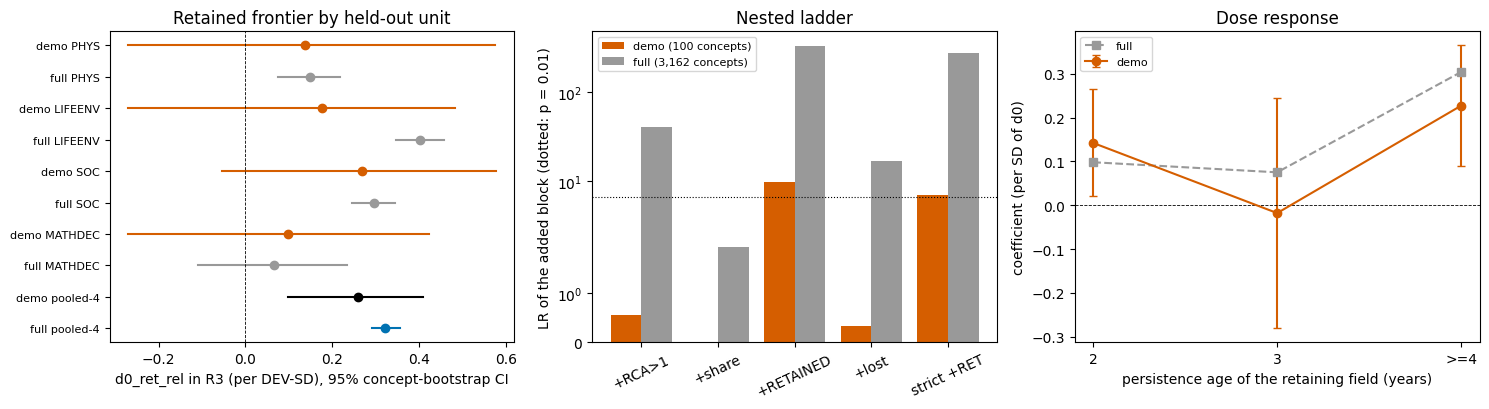

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
# (1) forest plot of d0 in R3: per unit + pooled, demo vs published
ax = axes[0]
rows = []
for u in HELD4:
    v = res["units"][u]["d0_R3"]
    rows.append((f"demo {u}", v["coef"], *v["boot_ci"], "#D55E00"))
    r_ = ref["units_d0_R3"][u]
    rows.append((f"full {u}", r_["coef"], *r_["boot_ci"], "#999999"))
rows.append(("demo pooled-4", d0, *ci, "#000000"))
rows.append(("full pooled-4", ref["d0_R3"]["est"], *ref["d0_R3"]["ci"], "#0072B2"))
for i, (lab, b_, lo, hi, col) in enumerate(rows[::-1]):
    ax.plot([lo, hi], [i, i], color=col, lw=1.5); ax.plot(b_, i, "o", color=col)
ax.axvline(0, color="k", ls="--", lw=0.6)
ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows[::-1]], fontsize=8)
ax.set_xlabel("d0_ret_rel in R3 (per DEV-SD), 95% concept-bootstrap CI"); ax.set_title("Retained frontier by held-out unit")
# (2) ladder LRs: demo vs full
ax = axes[1]
steps = [("R1_rca_vs_R0_M0", "+RCA>1"), ("R2_vol_vs_R1_rca", "+share"), ("R3_ret_vs_R2_vol", "+RETAINED"),
         ("R4_lost_vs_R3_ret", "+lost"), ("S_strict_vs_S_strict0", "strict +RET")]
x = np.arange(len(steps))
ax.bar(x - 0.2, [lad["LR"][k]["LR"] for k, _ in steps], 0.4, label="demo (100 concepts)", color="#D55E00")
ax.bar(x + 0.2, [ref["LR"][k] for k, _ in steps], 0.4, label="full (3,162 concepts)", color="#999999")
ax.set_yscale("symlog"); ax.axhline(6.63, color="k", ls=":", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([s for _, s in steps], rotation=25)
ax.set_ylabel("LR of the added block (dotted: p = 0.01)"); ax.legend(fontsize=8); ax.set_title("Nested ladder")
# (3) dose response by persistence age
ax = axes[2]
fd = p4["specificity_table_only"]["c_dose"]["fit"]
bdose = [fd[c]["coef"] for c in ("d_ret_a2", "d_ret_a3", "d_ret_a4p")]
sdose = [fd[c]["se_concept"] for c in ("d_ret_a2", "d_ret_a3", "d_ret_a4p")]
ax.errorbar(range(3), bdose, yerr=1.96 * np.array(sdose), fmt="o-", color="#D55E00", capsize=3, label="demo")
ax.plot(range(3), [0.098, 0.075, 0.304], "s--", color="#999999", label="full")
ax.axhline(0, color="k", ls="--", lw=0.6)
ax.set_xticks(range(3)); ax.set_xticklabels(["2", "3", ">=4"])
ax.set_xlabel("persistence age of the retaining field (years)"); ax.set_ylabel("coefficient (per SD of d0)")
ax.legend(fontsize=8); ax.set_title("Dose response")
plt.tight_layout(); plt.show()